# 1. Basic

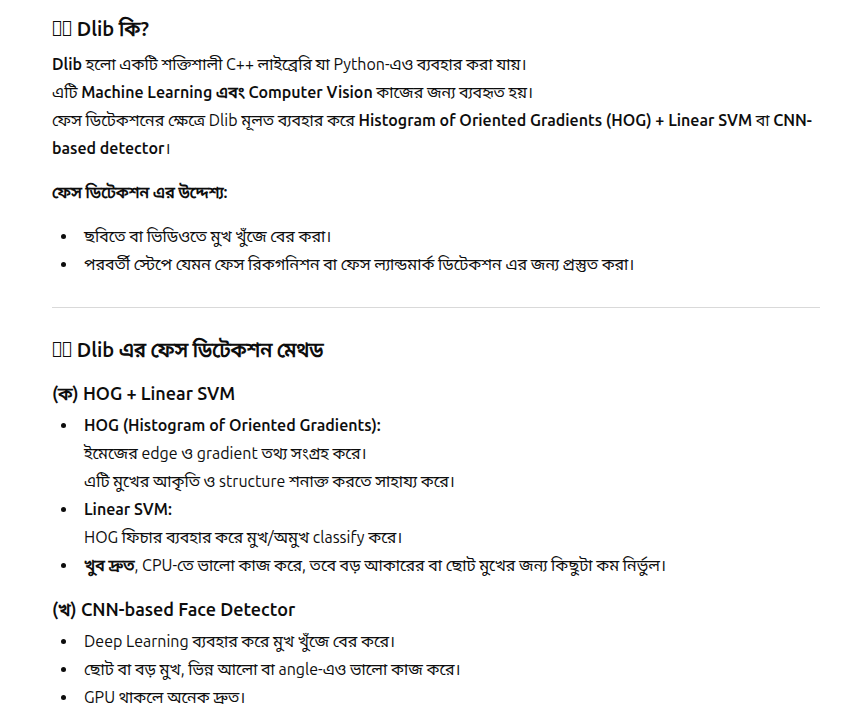

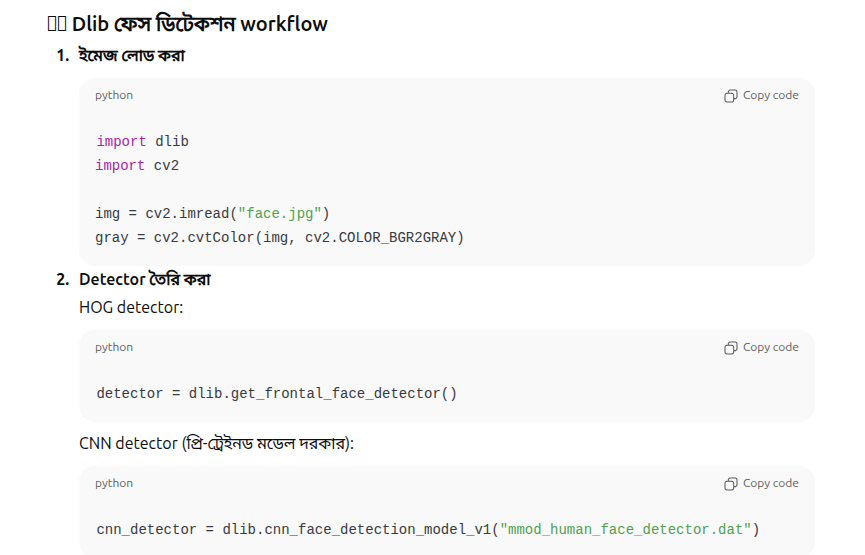

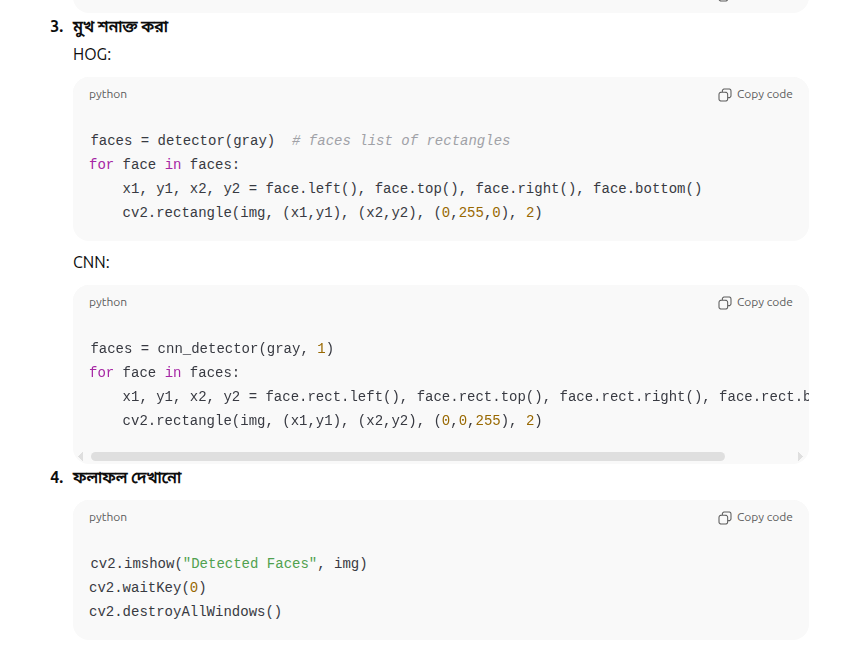

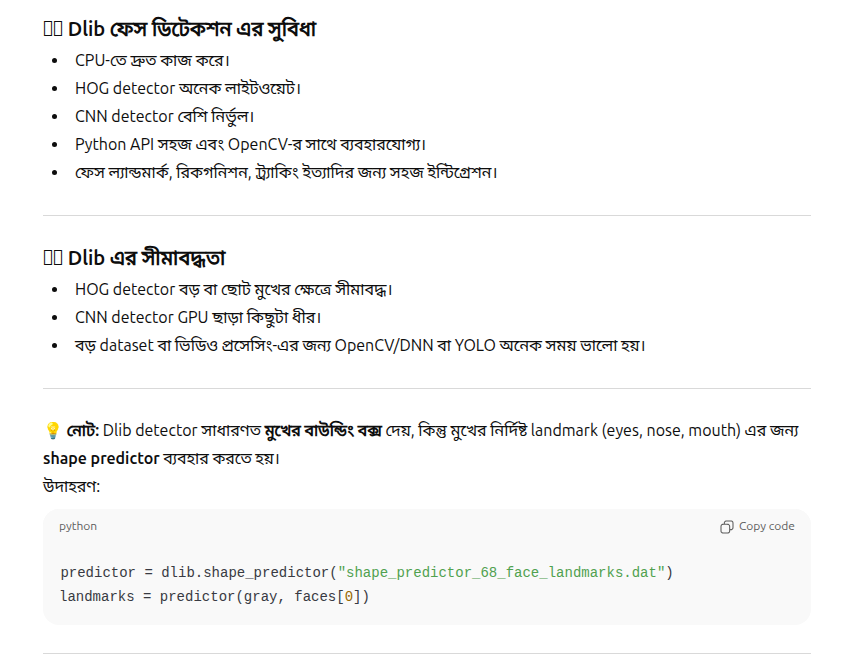

## 1. Individual Image (একটি ছবি)

In [ ]:
import dlib
import cv2

# Step 1: ইমেজ লোড
img = cv2.imread("../dataset/test/sinner.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 2: HOG detector লোড
detector = dlib.get_frontal_face_detector()

# Step 3: মুখ শনাক্ত
faces = detector(gray)

# Step 4: মুখের চারপাশে rectangle
for face in faces:
    x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Step 5: দেখানো
cv2.imshow("Detected Faces", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

## 2. Video File (ভিডিও ফাইল)

In [3]:
import dlib
import cv2

# Step 1: ভিডিও লোড
cap = cv2.VideoCapture("../dataset/vid/s.mp4")

detector = dlib.get_frontal_face_detector()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    for face in faces:
        x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cv2.imshow("Video Face Detection", frame)
    if cv2.waitKey(1) & 0xFF == 27:  # Esc চাপলে বন্ধ হবে
        break

cap.release()
cv2.destroyAllWindows()

## 3. Webcam (লাইভ ক্যামেরা)

In [4]:
import dlib
import cv2

cap = cv2.VideoCapture(0)  # 0 মানে default webcam

detector = dlib.get_frontal_face_detector()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    for face in faces:
        x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cv2.imshow("Webcam Face Detection", frame)
    if cv2.waitKey(1) & 0xFF == 27:  # Esc চাপলে বন্ধ হবে
        break

cap.release()
cv2.destroyAllWindows()

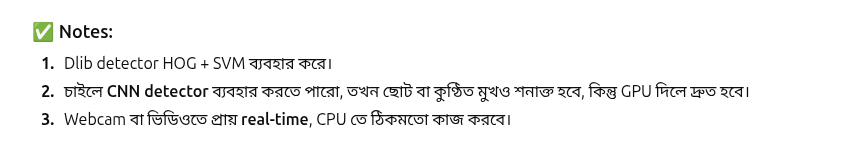

# 2. Tips

## 1. CNN-Based Individual Image Face Detection

In [1]:
import cv2
import dlib

# Step 1: CNN Face Detector Load (Decompressed .dat file)
cnn_detector = dlib.cnn_face_detection_model_v1("mmod_human_face_detector.dat")

# Step 2: Load Image
image_path = "../dataset/test/ronaldo.jpg"
img = cv2.imread(image_path)

# Step 3: Convert to RGB (CNN expects RGB)
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 4: Detect Faces
faces = cnn_detector(rgb_img, 1)

# Step 5: Draw Results
for face in faces:
    x1, y1, x2, y2 = face.rect.left(), face.rect.top(), face.rect.right(), face.rect.bottom()
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.putText(img, "Face", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

# Step 6: Show Result
cv2.imshow("CNN Face Detection", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

## 2. CNN-Based Video Face Detection

In [ ]:
import dlib
import cv2

# Input Video Path
video_path = "../dataset/vid/s.mp4"

# Step 1: Load CNN Face Detector
# mmod_human_face_detector.dat ডাউনলোড করতে হবে
cnn_detector = dlib.cnn_face_detection_model_v1("mmod_human_face_detector.dat")

# Step 2: Open Video
cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Step 3: Convert to RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Step 4: Detect Faces (upsample=1 for small faces)
    faces = cnn_detector(rgb_frame, 1)

    # Step 5: Draw rectangles
    for face in faces:
        x1, y1, x2, y2 = face.rect.left(), face.rect.top(), face.rect.right(), face.rect.bottom()
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(frame, "Face", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

    # Step 6: Show Video Frame
    cv2.imshow("CNN Video Face Detection", frame)

    # Exit on Esc key
    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

## 3. CNN-Based Webcam Face Detection

In [2]:
import dlib
import cv2

# Step 1: Open Webcam
cap = cv2.VideoCapture(0)  # 0 = default webcam

# Step 2: Load CNN Face Detector
# mmod_human_face_detector.dat ডাউনলোড করতে হবে
cnn_detector = dlib.cnn_face_detection_model_v1("mmod_human_face_detector.dat")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Step 3: Convert to RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Step 4: Detect Faces (upsample=1 for small faces)
    faces = cnn_detector(rgb_frame, 1)

    # Step 5: Draw rectangles
    for face in faces:
        x1, y1, x2, y2 = face.rect.left(), face.rect.top(), face.rect.right(), face.rect.bottom()
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(frame, "Face", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

    # Step 6: Show Webcam Frame
    cv2.imshow("CNN Webcam Face Detection", frame)

    # Exit on Esc key
    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()